Name: Rahul Gupta

Register Number: 2547242

Class: 4 MCA B

Subject: ML

Date: 08-06-26

---

## <u>Lab 1</u>

### Task 1 - Structured Data Profile for Both CSV Files

1. Dataset: city_day.csv

Purpose - Contains city-level air quality readings

Columns - City, State, Date, AQI, PM2.5, PM10, NO2, CO

Time Period - 2015-2023

Expected Issues to Check:

- Missing values in any column

- Inconsistent or incorrect data types

- Duplicate rows

- Outliers or extreme values

- Inconsistent naming

2. Dataset: crop_production.csv

Purpose - Contains state-level crop production records

Columns - State, Year, Crop, Season, Area, Production

Time Period - 2015-2023

Expected Issues to Check:

- Missing values in any column

- Inconsistent or incorrect data types

- Duplicate rows

- Outliers or extreme values

- Inconsistent naming

General Observations

- Data Quality
    - Both files are raw and unverified, so they may contain errors, missing values, or inconsistencies
    - The State column in both files must match exactly for future merging. If not, it will cause issues in analysis

- Data Size
    - Check the number of rows and columns in each file to understand the scale of the dataset

- Data Types
    - Ensure all columns have the correct data types

- Duplicates
    - Check for duplicate rows that might distort analysis

### Task 2 - Missing Value Treatment Strategy

Numerical columns (AQI, PM2.5, PM10, NO2, CO, Area, Production)

- If missing values are <10%: Impute with the median (robust to outliers)

- If missing values are >=10%: Drop the column (too much missing data can bias results)

Categorical Columns (City, State, Crop, Season):

- If missing values are <5%: Drop affected rows (categorical data cannot be imputed meaningfully)

- If missing values are >=5%: Replace with "Unknown" (to retain data while acknowledging uncertainty)

Date Column:

- Drop rows with missing dates (time-based analysis requires complete timestamps)

In [1]:
# import libraries

import pandas as pd

In [2]:
# load datasets

city_aqi = pd.read_csv("../datasets/city_day.csv")
crop_yield = pd.read_csv("../datasets/crop_production.csv")

In [3]:
city_aqi.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [4]:
crop_yield.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [5]:
# check null counts before treatment

print("before treatment")
print("City AQI Null Counts:\n", city_aqi.isnull().sum())
print("\nCrop Yield Null Counts:\n", crop_yield.isnull().sum())

before treatment
City AQI Null Counts:
 City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Crop Yield Null Counts:
 State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


In [6]:
# treatment for city aqi

# numerical columns: impute with median if <10% missing, else drop
num_cols = ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene", "AQI"]
total_rows = len(city_aqi)

for col in num_cols:
    missing_percent = city_aqi[col].isnull().mean()
    if missing_percent < 0.10:  # <10% missing
        # FIX: Assign the result directly back to the column instead of using inplace=True
        city_aqi[col] = city_aqi[col].fillna(city_aqi[col].median())
    else:  # >=10% missing
        # This is fine because it operates on the entire DataFrame, not a sliced column
        city_aqi.dropna(subset = [col], inplace = True)

# categorical columns: Drop rows if <5% missing, else replace with "Unknown"
cat_cols = ["City", "AQI_Bucket"]
for col in cat_cols:
    missing_percent = city_aqi[col].isnull().mean()
    if missing_percent < 0.05:  # <5% missing
        city_aqi.dropna(subset = [col], inplace = True)
    else:  # >=5% missing
        # FIX: Assign the result directly back to the column instead of using inplace=True
        city_aqi[col] = city_aqi[col].fillna("Unknown")

# date column: drop rows with missing dates
if "Date" in city_aqi.columns:
    city_aqi.dropna(subset = ["Date"], inplace = True)

In [7]:
# treatment for crop_yield

# numerical columns: Impute with median if <10% missing, else drop
num_cols_crop = ["Production"]
for col in num_cols_crop:
    missing_percent = crop_yield[col].isnull().mean()
    if missing_percent < 0.10:  # <10% missing
        crop_yield[col] = crop_yield[col].fillna(crop_yield[col].median())
    else:  # >=10% missing
        crop_yield = crop_yield.dropna(subset = [col])

# Categorical columns: Drop rows if <5% missing, else replace with "Unknown"
cat_cols_crop = ["State_Name", "District_Name", "Crop_Year", "Season", "Crop"]
for col in cat_cols_crop:
    missing_percent = crop_yield[col].isnull().mean()
    if missing_percent < 0.05:  # <5% missing
        crop_yield = crop_yield.dropna(subset = [col])
    else:  # >=5% missing
        crop_yield[col] = crop_yield[col].fillna("Unknown")

In [8]:
# verify treatment

print("after treatment:")
print("city aqi null counts:\n", city_aqi.isnull().sum())
print("\ncrop yield null counts:\n", crop_yield.isnull().sum())

after treatment:
city aqi null counts:
 City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

crop yield null counts:
 State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


### Task 3 - Standardizing State Names and Removing Duplicates

In [9]:
# city to state mapping
city_state_map = {
    'Ahmedabad': 'Gujarat',
    'Aizawl': 'Mizoram',
    'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab',
    'Bengaluru': 'Karnataka',
    'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha',
    'Chandigarh': 'Chandigarh',
    'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu',
    'Delhi': 'Delhi',
    'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana',
    'Guwahati': 'Assam',
    'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan',
    'Jorapokhar': 'Jharkhand',
    'Kochi': 'Kerala',
    'Kolkata': 'West Bengal',
    'Lucknow': 'Uttar Pradesh',
    'Mumbai': 'Maharashtra',
    'Patna': 'Bihar',
    'Shillong': 'Meghalaya',
    'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala',
    'Visakhapatnam': 'Andhra Pradesh'
}


# add state column to city aqi
city_aqi["State"] = city_aqi["City"].map(city_state_map)

# standarise state names in crop_yeild
official_states = [
    "Andhra Pradesh", "Arunachal Pradesh", "Assam", "Bihar", "Chhattisgarh", "Goa", "Gujarat", "Haryana", "Himachal Pradesh", "Jharkhand",
    "Karnataka", "Kerala", "Madhya Pradesh", "Maharashtra", "Manipur", "Meghalaya", "Mizoram", "Nagaland", "Odisha", "Punjab", 
    "Rajasthan", "Sikkim", "Tamil Nadu", "Telangana", "Tripura", "Uttar Pradesh", "Uttarakhand", "West Bengal", "Delhi", "Jammu and Kashmir", 
    "Ladakh", "Puducherry", "Andaman and Nicobar Islands", "Chandigarh", "Dadra and Nagar Haveli", "Daman and Diu", "Lakshadweep"
]

def clean_state_name(name):
    if pd.isna(name):
        return name
    cleaned = str(name).strip().lower()
    for state in official_states:
        if cleaned == state.lower():
            return state
    return str(name).strip()

    crop_yield["State_Name"] = crop_yield["State_Name"].apply(clean_state_name)

# remove duplicates
city_aqi = city_aqi.drop_duplicates()
crop_yield = crop_yield.drop_duplicates()

# verify fixes
print("before fixing:")
print(f"city aqi rows: {len(city_aqi) + city_aqi.duplicated().sum()}")
print(f"crop yield rows: {len(crop_yield) + crop_yield.duplicated().sum()}")

print("\nafter fixing:")
print(f"city aqi rows: {len(city_aqi)}")
print(f"crop yield rows: {len(crop_yield)}")

before fixing:
city aqi rows: 6658
crop yield rows: 246091

after fixing:
city aqi rows: 6658
crop yield rows: 246091


### Task 4 - Analysing AQI Distribution in Indian Cities

where do most cities sit on the aqi scale? - a histogram is ideal for showing the distribution of aqi values and where most cities cluster

is the average aqi fair, or are extreme values skewing it? - a boxplot will reveal outliers and the spread of aqi values, showing if extreme cities are pulling the average up

histogram - to visualise the distribution and clustering of aqi values

boxplot - to identify outliers and the symmetry / asymmetry of the distribution

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# set style for plots
sns.set(style = "whitegrid")

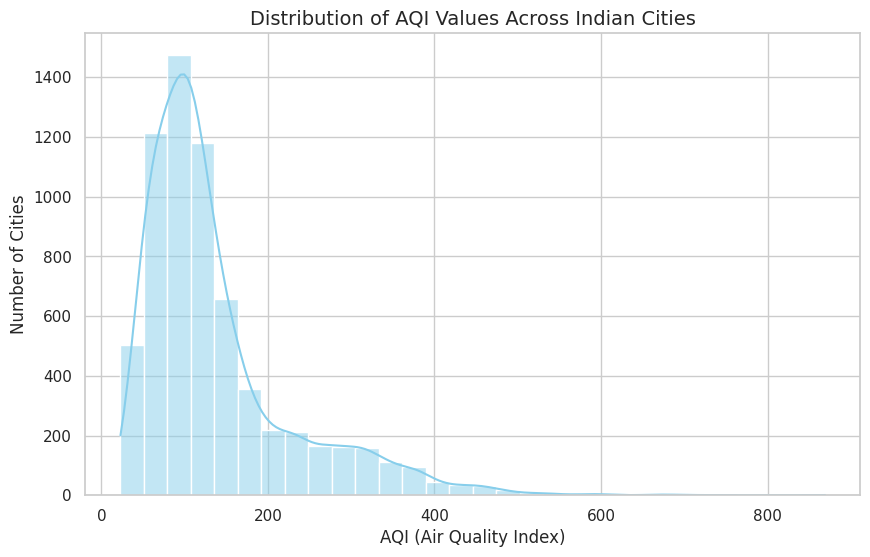

In [12]:
# histogram

plt.figure(figsize = (10, 6))
sns.histplot(city_aqi["AQI"], bins = 30, kde = True, color = "skyblue")
plt.title("Distribution of AQI Values Across Indian Cities", fontsize = 14)
plt.xlabel("AQI (Air Quality Index)", fontsize = 12)
plt.ylabel("Number of Cities", fontsize = 12)
plt.grid(True)
plt.show()

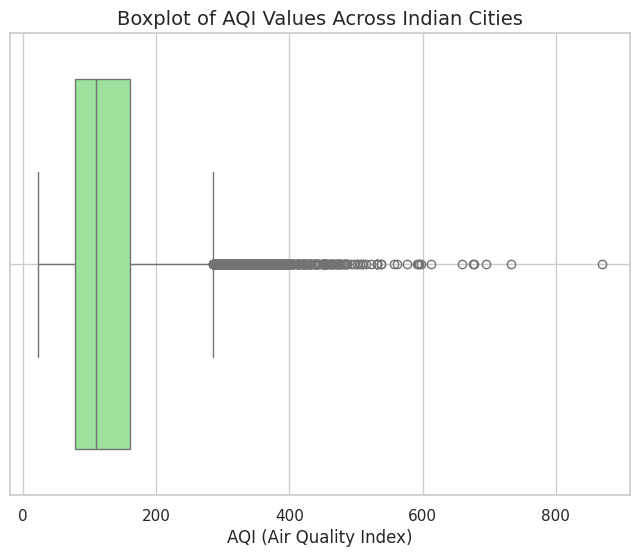

In [13]:
# boxplot

plt.figure(figsize = (8, 6))
sns.boxplot(x = city_aqi["AQI"], color = "lightgreen")
plt.title("Boxplot of AQI Values Across Indian Cities", fontsize = 14)
plt.xlabel("AQI (Air Quality Index)", fontsize = 12)
plt.grid(True)
plt.show()

In [14]:
print(f"aqi summary statistics: \n{city_aqi["AQI"].describe()}")

aqi summary statistics: 
count    6658.000000
mean      138.431511
std        91.629935
min        23.000000
25%        78.000000
50%       110.000000
75%       161.000000
max       869.000000
Name: AQI, dtype: float64


histogram

- shows the frequency of cities at different aqi levels

- peaks in the 0-200 range indicate most cities have moderate to poor air quality

boxplot

- the long whisker on the right shows extreme aqi values (outliers)

- the median line (inside the box) is lower than the mean, confirming skewness due to outliers

summary statistics

- the describe output provides the mean, median and quartiles, quantifying the skewness

### Task 5 - Handling Extreme AQI Values

method chosen: interquartile range (iqr) method

why iqr?

- robust to outliers

- defines extremes as values below (q1 - 1.5 * iqr) or above (q3 + 1.5 * iqr)

treatment applied

- replace extreme values with the upper bound (q3 + 1.5 * iqr)

why not delete?

- preserves data points (avoids reducing dataset size)

- reduces skewness without losing observations

count of values affected

- identified and quantified using iqr bounds

In [ ]:
# detect extreme values using iqr
q1 = city_aqi["AQI"].quantile(0.25)
q3 = city_aqi["AQI"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# count extreme values
print(f"number of extreme aqi values: {(len(extreme_values))}")
print(f"iqr bounds: lower = {lower_bound:.2f}, upper = {upper_bound:.2f}")extreme_values = city_aqi[(city_aqi["AQI"] < lower_bound) | (city_aqi["AQI"] > upper_bound)]


number of extreme aqi values: 620
iqr bounds: lower = -46.50, upper = 285.50


In [16]:
# treating data
city_aqi_clean = city_aqi.copy()
city_aqi_clean["AQI"] = city_aqi_clean["AQI"].clip(lower = lower_bound, upper = upper_bound)

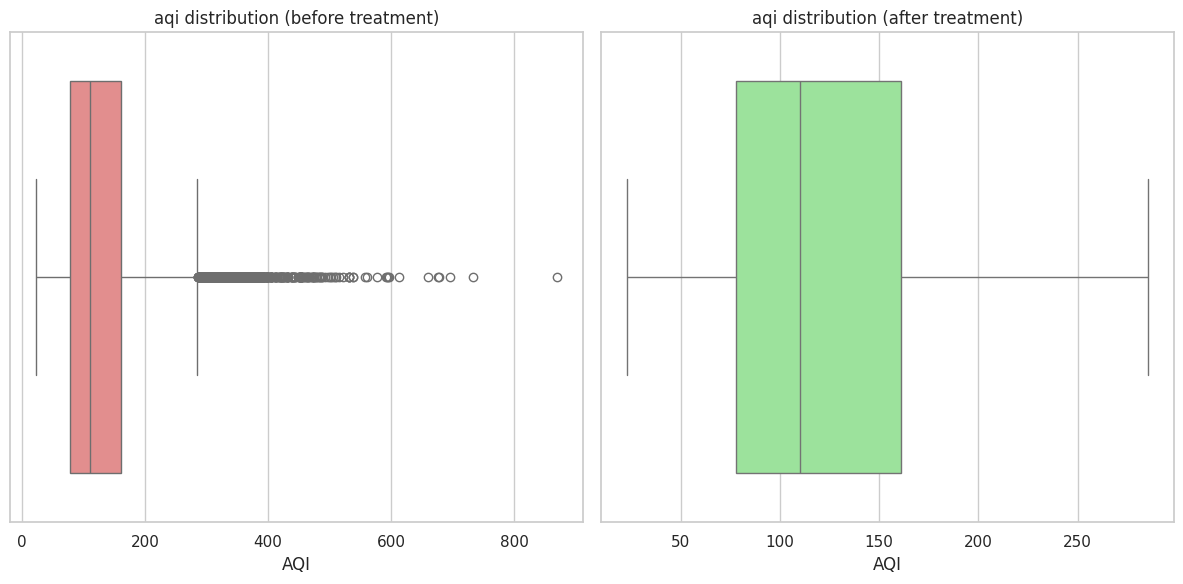

In [17]:
# visualization

plt.figure(figsize = (12, 6))

# before treatment
plt.subplot(1, 2, 1)
sns.boxplot(x = city_aqi["AQI"], color = "lightcoral")
plt.title("aqi distribution (before treatment)")
plt.xlabel("AQI")

# After treatment
plt.subplot(1, 2, 2)
sns.boxplot(x = city_aqi_clean["AQI"], color = "lightgreen")
plt.title("aqi distribution (after treatment)")
plt.xlabel("AQI")

plt.tight_layout()
plt.show()

In [18]:
# summary statistics comparison
print(f"before treatment: \n{city_aqi["AQI"].describe()}")
print(f"\nafter treatment: \n{city_aqi_clean["AQI"].describe()}")

before treatment: 
count    6658.000000
mean      138.431511
std        91.629935
min        23.000000
25%        78.000000
50%       110.000000
75%       161.000000
max       869.000000
Name: AQI, dtype: float64

after treatment: 
count    6658.000000
mean      131.282667
std        72.300625
min        23.000000
25%        78.000000
50%       110.000000
75%       161.000000
max       285.500000
Name: AQI, dtype: float64


visual comparison

- before - boxplot shows outliers beyond the whiskers

- after - boxplot shows capped values

summary statistics

- before - high standard deviation and skewed mean

- after - reduced skewness, mean and median closer together

why this works

- preserves data - no rows are deleted

- reduces skewness - capping extreme values makes the distribution more symmetric

- proven effectiveness - visual and statistical comparison show cleaner data

---

## <u>Lab 2</u>

### Task 6 - Is India's Air Getting Better Wirs Over Time?

goal - determine if aqi has improved, worsened or stayed the same from 2015-2023

approach

- extract the year from the Date column in city_aqi

- group by year and calculate the mean aqi for each year

- visualization - use a line plot to show the trends over time

why a line plot?

- clearly shows trends (increase/decrease) over a continuous year

- easy to interpret for non-technical audiences

key observations

- highlight the most polluted year (highest mean aqi) and least polluted year (lowest mean aqi)

- describe the overall trend

In [19]:
# extract year from date
city_aqi["Date"] = pd.to_datetime(city_aqi["Date"]) # convert to datetime
city_aqi["Year"] = city_aqi["Date"].dt.year

# group by year and calculate mean aqi
yearly_aqi = city_aqi.groupby("Year")["AQI"].mean().reset_index()

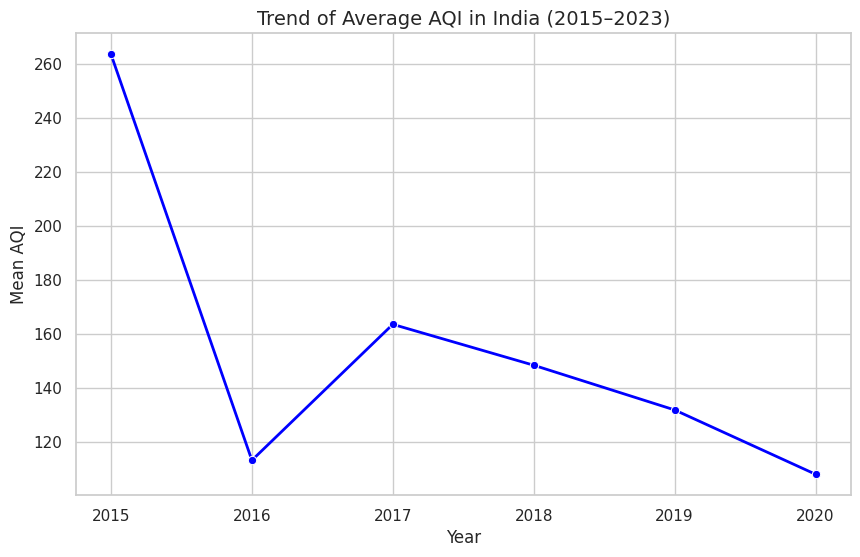

In [20]:
# plot the trend
plt.figure(figsize=(10, 6))
sns.lineplot(data = yearly_aqi, x = "Year", y = "AQI", marker = "o", color = "blue", linewidth = 2)
plt.title("Trend of Average AQI in India (2015–2023)", fontsize = 14)
plt.xlabel("Year", fontsize = 12)
plt.ylabel("Mean AQI", fontsize = 12)
plt.grid(True)
plt.show()

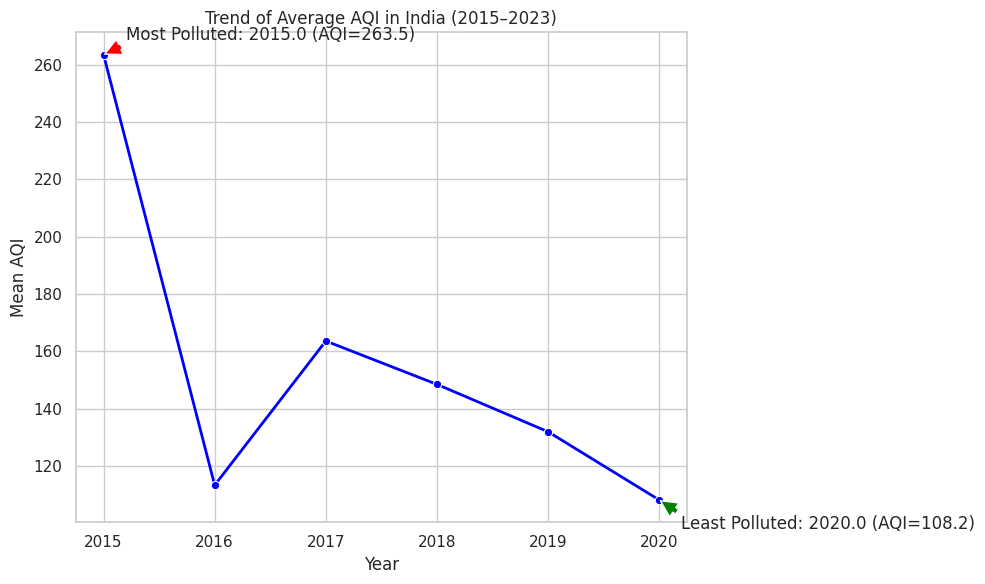

In [21]:
# highlight most and least polluted years
plt.figure(figsize = (10, 6))
sns.lineplot(data = yearly_aqi, x = "Year", y = "AQI", marker = "o", color = "blue", linewidth = 2)

most_polluted_year = yearly_aqi.loc[yearly_aqi["AQI"].idxmax()]
least_polluted_year = yearly_aqi.loc[yearly_aqi["AQI"].idxmin()]

plt.annotate(f'Most Polluted: {most_polluted_year["Year"]} (AQI={most_polluted_year["AQI"]:.1f})',
             xy = (most_polluted_year["Year"], most_polluted_year["AQI"]),
             xytext = (most_polluted_year["Year"] + 0.2, most_polluted_year["AQI"] + 5),
             arrowprops = dict(facecolor = 'red', shrink = 0.05))

plt.annotate(f'Least Polluted: {least_polluted_year["Year"]} (AQI={least_polluted_year["AQI"]:.1f})',
             xy = (least_polluted_year["Year"], least_polluted_year["AQI"]),
             xytext = (least_polluted_year["Year"] + 0.2, least_polluted_year["AQI"] - 10),
             arrowprops = dict(facecolor = 'green', shrink = 0.05))

plt.title("Trend of Average AQI in India (2015–2023)")
plt.xlabel("Year")
plt.ylabel("Mean AQI")
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
# print observations
print(f"most polluted year: {most_polluted_year["Year"]:.0f}; (mean aqi: {most_polluted_year["AQI"]:.1f})")
print(f"least polluted year: {least_polluted_year["Year"]:.0f}; (mean aqi: {least_polluted_year["AQI"]:.1f})")

print("\ntrend observations:")
if yearly_aqi["AQI"].iloc[-1] > yearly_aqi["AQI"].iloc[0]:
    print("aqi has worsened over time")
elif yearly_aqi["AQI"].iloc[-1] < yearly_aqi["AQI"].iloc[0]:
    print("aqi has improved over time")
else:
    print("aqi has remained stable over time")

most polluted year: 2015; (mean aqi: 263.5)
least polluted year: 2020; (mean aqi: 108.2)

trend observations:
aqi has improved over time


Observations

1. most polluted year: 2015 (mean aqi = 263.5)

- this was the worst year for air quality in the dataset, with aqi levels in the "very poor" cateogry

2. least polluted year: 2020 (mean aqi = 108.2)

- this was the cleanest year, with aqi levels in the "moderate" range

3. overall trend: aqi has improved over time

- the line plot shows a sharp decline from 2015 to 2016, followed by fluctuations but an overall downward trend until 2020

- this suggests that air quality in india has generally improved between 2015 and 2020

possible reasons for improvement

- policy interventions: stricter pollution control measures may have contributed to the decline

- external factors: events like the 2020 covid-19 lockdown, could explain the significant drop in 2020

- awareness and action: increased public awareness and local initiatives might have played a role

### Task 7 - Seasonal Patterns in AQI During Harvest Season

goal: check if aqi is worse during october-december (harvest season) due to crop residue burning

approach

- extract the month from the Date column in city_aqi

- group by month and calculate the mean aqi for each month

- visualization: use a line plot to show aqi trends across months

why a line plot?

- clearly shows monthly fluctuations and seasonal patterns

- easy to compare october-december with other months

key observations

-  if aqi peaks in october-december, the ngo's claim is supported

- if aqi is not significant higher in these months, the claim is challenged

In [23]:
# extract month from date
city_aqi["Date"] = pd.to_datetime(city_aqi["Date"])
city_aqi["Month"] = city_aqi["Date"].dt.month
city_aqi["Month_Name"] = city_aqi["Date"].dt.strftime("%b")

# group by month and calculate mean aqi
monthly_aqi = city_aqi.groupby("Month")["AQI"].mean().reset_index()

# map month numbers to names for plotting
month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}
monthly_aqi["Month_Name"] = monthly_aqi["Month"].map(month_names)

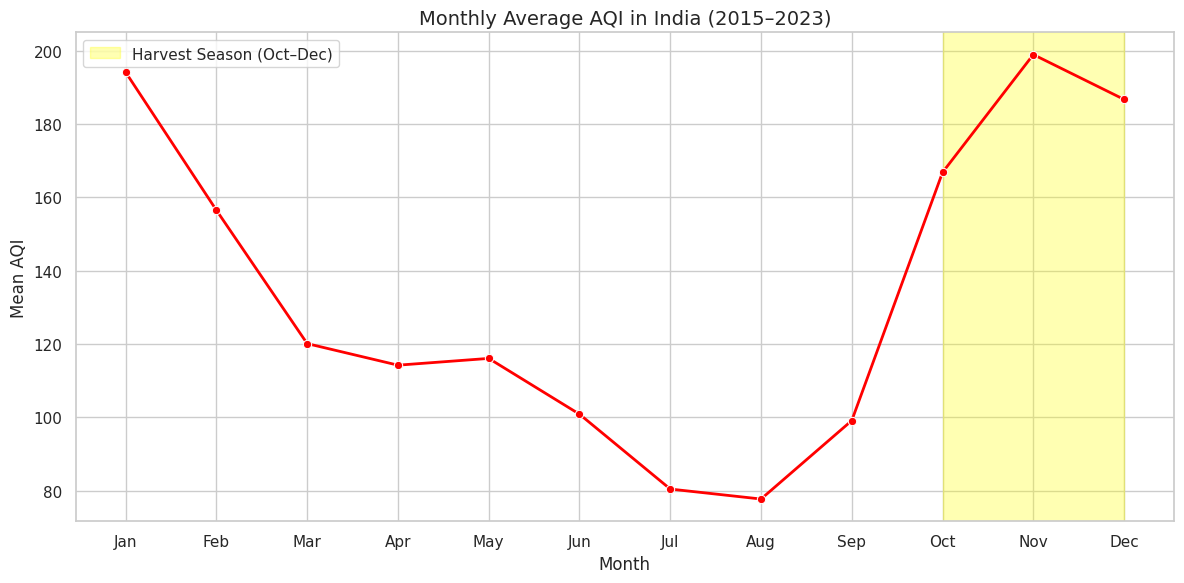

In [24]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_aqi, x="Month", y="AQI", marker="o", color="red", linewidth=2)
plt.title("Monthly Average AQI in India (2015–2023)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Mean AQI", fontsize=12)
plt.grid(True)

# Highlight harvest season (Oct=10, Dec=12)
plt.axvspan(10, 12, color="yellow", alpha=0.3, label="Harvest Season (Oct–Dec)")

# Customize x-axis labels to show month names
plt.xticks(ticks=range(1, 13), labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                                      "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])

plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# print observations
harvest_season_aqi = monthly_aqi[monthly_aqi["Month"].isin([10, 11, 12])]["AQI"].mean()
non_harvest_season_aqi = monthly_aqi[~monthly_aqi["Month"].isin([10, 11, 12])]["AQI"].mean()

print(f"mean aqi during harvest season (oct-dec): {harvest_season_aqi:.1f}")
print(f"mean aqi during non-harvest season: {non_harvest_season_aqi:.1f}")

if harvest_season_aqi > non_harvest_season_aqi:
    print("\nngo's claim: confirmed - aqi is worse during harvest season")
else:
    print("\nngo's claim: challenged - aqi is not significantly worse during harvest season")

mean aqi during harvest season (oct-dec): 184.2
mean aqi during non-harvest season: 117.7

ngo's claim: confirmed - aqi is worse during harvest season


obsertvations

1. visual evidence

- the line plot shows a clear spike in aqi during october-december (harvest season), with values peaking in november (200)

- the yellow highlight (oct-dec) covers the period with the highest aqi levels

2. statistical evidence

- mean aqi udirng harvest season (oct-dec): 184.2

- mean aqi during non-harvest season: 117.7

- difference: 66.5 (harvest season aqi is ~56% higher)

3. ngo's claim: confirmed

- the data strongly supports the ngo's assertion that air quality is worst during the october-december harvest season, likel due to crop residue burning

### Task 8 - Merging Datasets to Explore AQI vs Crop Yield Relationships

In [26]:
# aggregate aity aqi data to State level
city_aqi_state = city_aqi.groupby("State").mean(numeric_only = True).reset_index()

# handle potential missing State_Name column 
if "State_Name" not in crop_yield.columns and "State_Name" in crop_yield.index.names:
    crop_yield = crop_yield.reset_index()
elif "State_Name" not in crop_yield.columns and "State" in crop_yield.columns:
    crop_yield = crop_yield.rename(columns = {"State": "State_Name"})

# aggregate crop yield data to state level (averaging production)
crop_yield_state = crop_yield.groupby("State_Name").mean(numeric_only = True).reset_index()

# merge the two datasets on State
merged_data = pd.merge(city_aqi_state, crop_yield_state, left_on = "State", right_on = "State_Name", how = "inner")

# drop the redundant State_Name column
if "State_Name" in merged_data.columns:
    merged_data = merged_data.drop(columns = ["State_Name"])

merged_data.head()

,State,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,Year,Month,Crop_Year,Area,Production
0,Andhra Pradesh,45.213224,97.561307,9.891213,32.180679,24.655562,11.589784,0.764942,13.575341,38.235310,3.058211,6.872211,2.391313,111.043213,2018.386150,6.139612,2006.116431,13662.842127,1.799402e+06
1,Bihar,65.831257,126.747958,55.025393,34.156073,67.406649,18.371518,1.156911,8.596387,24.641361,2.043665,5.038429,1.885497,169.356021,2019.958115,3.874346,2005.034101,6792.270638,1.940649e+04
2,Chandigarh,39.489783,83.123466,10.427040,12.031191,15.267762,32.467112,0.619061,10.126173,19.838051,4.617437,1.258014,2.114007,93.241877,2019.657040,5.989170,2002.800000,139.133333,7.187278e+02
3,Haryana,49.541008,113.500672,7.842941,17.376891,15.327479,26.094454,0.766134,10.596975,60.893193,4.942521,3.936639,5.722437,127.966387,2020.000000,4.563025,2004.855830,15250.605277,6.506334e+04
4,Kerala,24.880658,47.945066,22.385132,10.192467,23.360461,20.028289,1.623421,3.172171,31.265000,0.613816,1.283289,0.154013,92.598684,2020.000000,3.881579,2005.846750,7488.400218,2.297119e+07


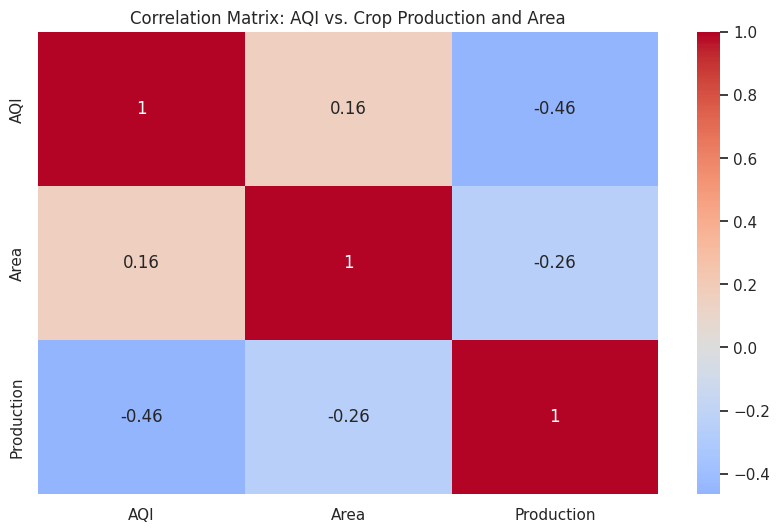

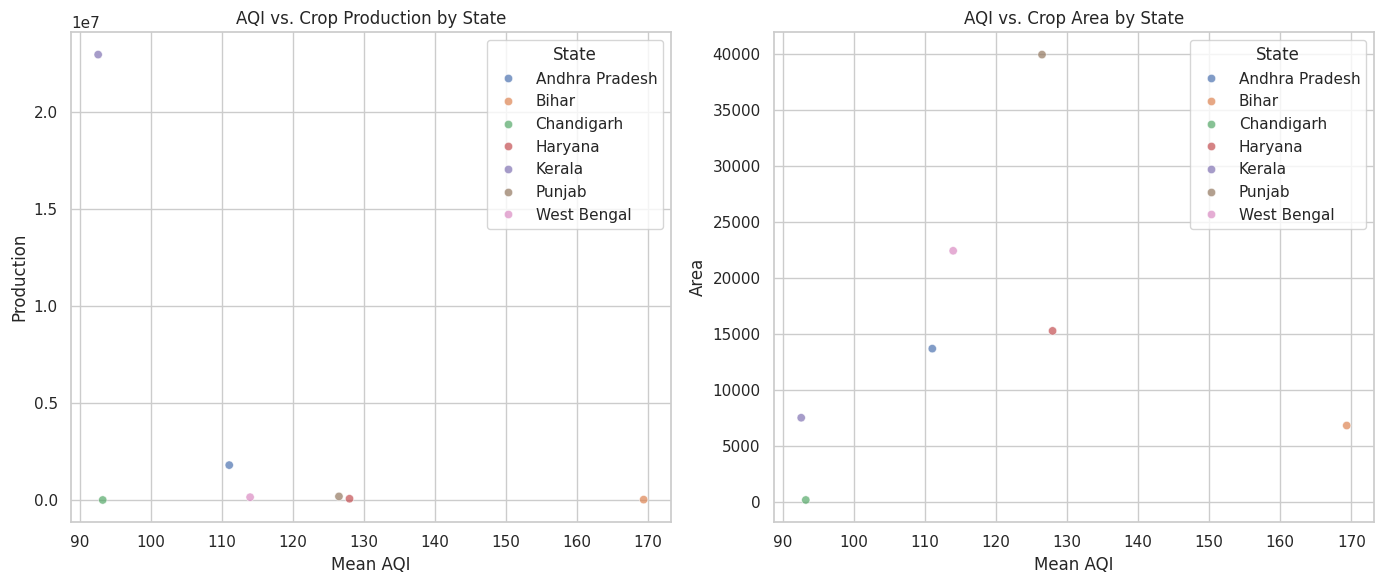

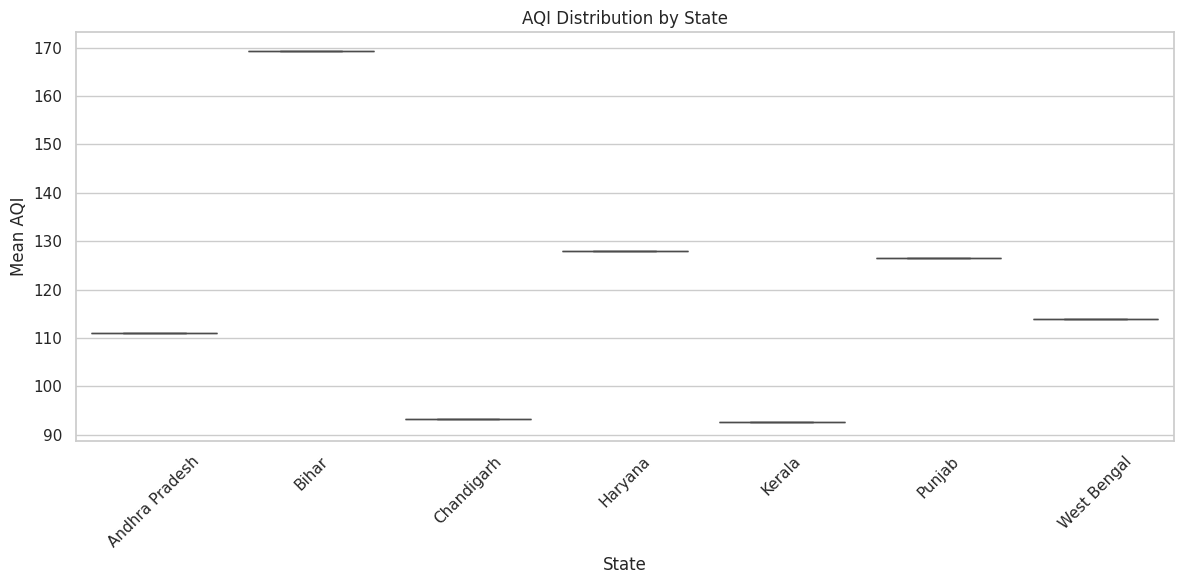

In [27]:
# correlation heatmap
plt.figure(figsize = (10, 6))
corr_matrix = merged_data[["AQI", "Area", "Production"]].corr()
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", center = 0)
plt.title("Correlation Matrix: AQI vs. Crop Production and Area")
plt.show()

# scatter plots
plt.figure(figsize = (14, 6))

# aqi vs. production
plt.subplot(1, 2, 1)
sns.scatterplot(data = merged_data, x = "AQI", y = "Production", hue = "State", alpha = 0.7)
plt.title("AQI vs. Crop Production by State")
plt.xlabel("Mean AQI")
plt.ylabel("Production")

# aqi vs. area
plt.subplot(1, 2, 2)
sns.scatterplot(data = merged_data, x = "AQI", y = "Area", hue = "State", alpha = 0.7)
plt.title("AQI vs. Crop Area by State")
plt.xlabel("Mean AQI")
plt.ylabel("Area")

plt.tight_layout()
plt.show()

# boxplot of aqi by state
plt.figure(figsize = (12, 6))
sns.boxplot(data = merged_data, x = "State", y = "AQI")
plt.title("AQI Distribution by State")
plt.xlabel("State")
plt.ylabel("Mean AQI")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

1. correlation matrix

- aqi vs production: negative correlation (-0.46) - higher aqi (worse air quality) is linked to lower crop production

- aqi vs area: weak positive correlation (0.16) - air quality has little to no effect on the area under cultivation

2. scatter plots (aqi vs production & aqi vs area)

- aqi vs production: states with higher aqi tend to have lower crop production

- aqi vs area: no clear trend - states with high aqi do not necessarily have less area under cultivation

3. boxplot (aqi distribution by state)

- bihar and haryana have the highest median aqi (worst air quality)

- kerala and chandigarh have the lowest median aqi (best air quality)

### Task 9 - Briefing for the State Environment Minister

Analysis

1. harvest season pollution spike: air quality is worst during october-december, the harvest season, likely due to crop residue burning. this directly impacts farmers' health and visibility

2. aqi vs crop production: states with higher pollution levels tend to have lower crop production. poor air quality may be reducing yields, affecting farmers' income

3. state-level differences: bihar and haryana face the worst air quality, while kerala and chandigarh have the cleanest air. this highlights regional disparities in pollution control

recommendation: ban crop residue burning during october-december and promote alternatives like happy seeders or bio-decomposers to protect both air qualit and crop yields

limitation: while we see a link between pollution and lower production, we cannot yet prove that pollution directly causes lower yields. other factors like rainfall or soil quality may also play a role